# EDA on Master Churn Dataset

**Goal:** Analyse the merged master dataset to identify which features are most critical for predicting churn (`Prospect_Outcome`).  
We focus on:
1. Target variable distribution & class balance
2. Billing scores vs churn
3. CRM / Email features vs churn
4. Customer-care call features vs churn
5. Renewal call features vs churn
6. Correlation heatmap & top predictors
7. Key categorical features

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

project_root = Path.cwd().parent.parent
df = pd.read_csv(project_root / "data" / "processed" / "master_churn_dataset.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (122082, 136)


,Co_Ref,Renewal_Month,Sustainability_Score,Total_Renewal_Score_New,Last_Years_Price,Auto_Renewal_Score,Status_Scores,Anchoring_Score,Tenure_Scores,Proforma_Auto_Renewal,...,ren_agent_renewal_pitch_category_mode,ren_customer_renewal_response_category_mode,ren_agent_response_category_mode,ren_membership_renewal_decision_mode,ren_customer_response_mode,ren_justification_category_mode,ren_reason_for_renewal_category_mode,ren_agent_response_to_cancel_category_mode,ren_argument_that_convinced_customer_to_stay_category_mode,Days_To_Close_Post_Renewal
0,VT6174,2024-11-01,8.0,42.5,799.0,9,9,7.5,9.0,Yes,...,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,0.0
1,VD3828,2025-08-01,8.0,41.5,799.0,9,9,7.5,8.0,Yes,...,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,0.0
2,DV8120,2025-03-01,8.0,33.0,799.0,8,0,7.5,9.5,Yes,...,Auto / Automatic,Cancellation / Termination / Non-Renewal / Wit...,Complaints,Pending/Unknown,Not Mentioned,Not Applicable,Not Applicable,Negotiation / Review,Not Applicable,0.0
3,EZ9894,2025-06-01,9.5,44.5,799.0,9,9,7.5,9.5,Yes,...,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,0.0
4,FA8957,2025-03-01,9.5,42.5,799.0,9,8,7.5,8.5,Yes,...,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,0.0


## 1. Target Variable Distribution

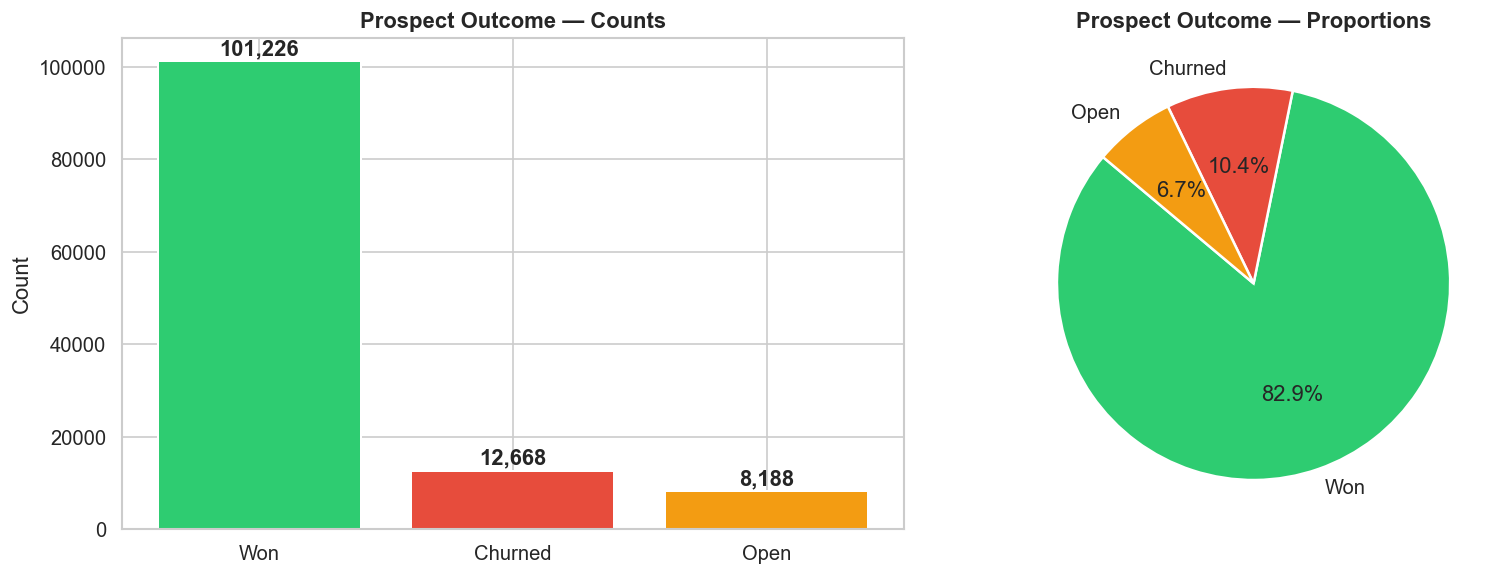


Binary dataset (Won vs Churned): (113894, 137)
Churn rate: 11.123%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = ["Won", "Churned", "Open"]
colors = {"Won": "#2ecc71", "Churned": "#e74c3c", "Open": "#f39c12"}
ax = axes[0]
counts = df["Prospect_Outcome"].value_counts().reindex(order)
bars = ax.bar(counts.index, counts.values, color=[colors[o] for o in order], edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Prospect Outcome — Counts", fontweight="bold")
ax.set_ylabel("Count")

# Percentage pie
ax2 = axes[1]
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=[colors[o] for o in order], startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Prospect Outcome — Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

# For modelling we'll focus on Won vs Churned (binary)
df_bin = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df_bin["churn_flag"] = (df_bin["Prospect_Outcome"] == "Churned").astype(int)
print(f"\nBinary dataset (Won vs Churned): {df_bin.shape}")
print(f"Churn rate: {df_bin['churn_flag'].mean():.3%}")

## 2. Billing Scores vs Churn

These scores are pre-computed in the billings data and capture renewal likelihood signals.

C:\Users\ShefaliChopra\AppData\Local\Temp\ipykernel_11668\3025679484.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bin, x="Prospect_Outcome", y=col, ax=axes[i],
C:\Users\ShefaliChopra\AppData\Local\Temp\ipykernel_11668\3025679484.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bin, x="Prospect_Outcome", y=col, ax=axes[i],
C:\Users\ShefaliChopra\AppData\Local\Temp\ipykernel_11668\3025679484.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bin, x="Prospect_Outcome", y=col, ax=axes[i],
C:\Users\ShefaliCho

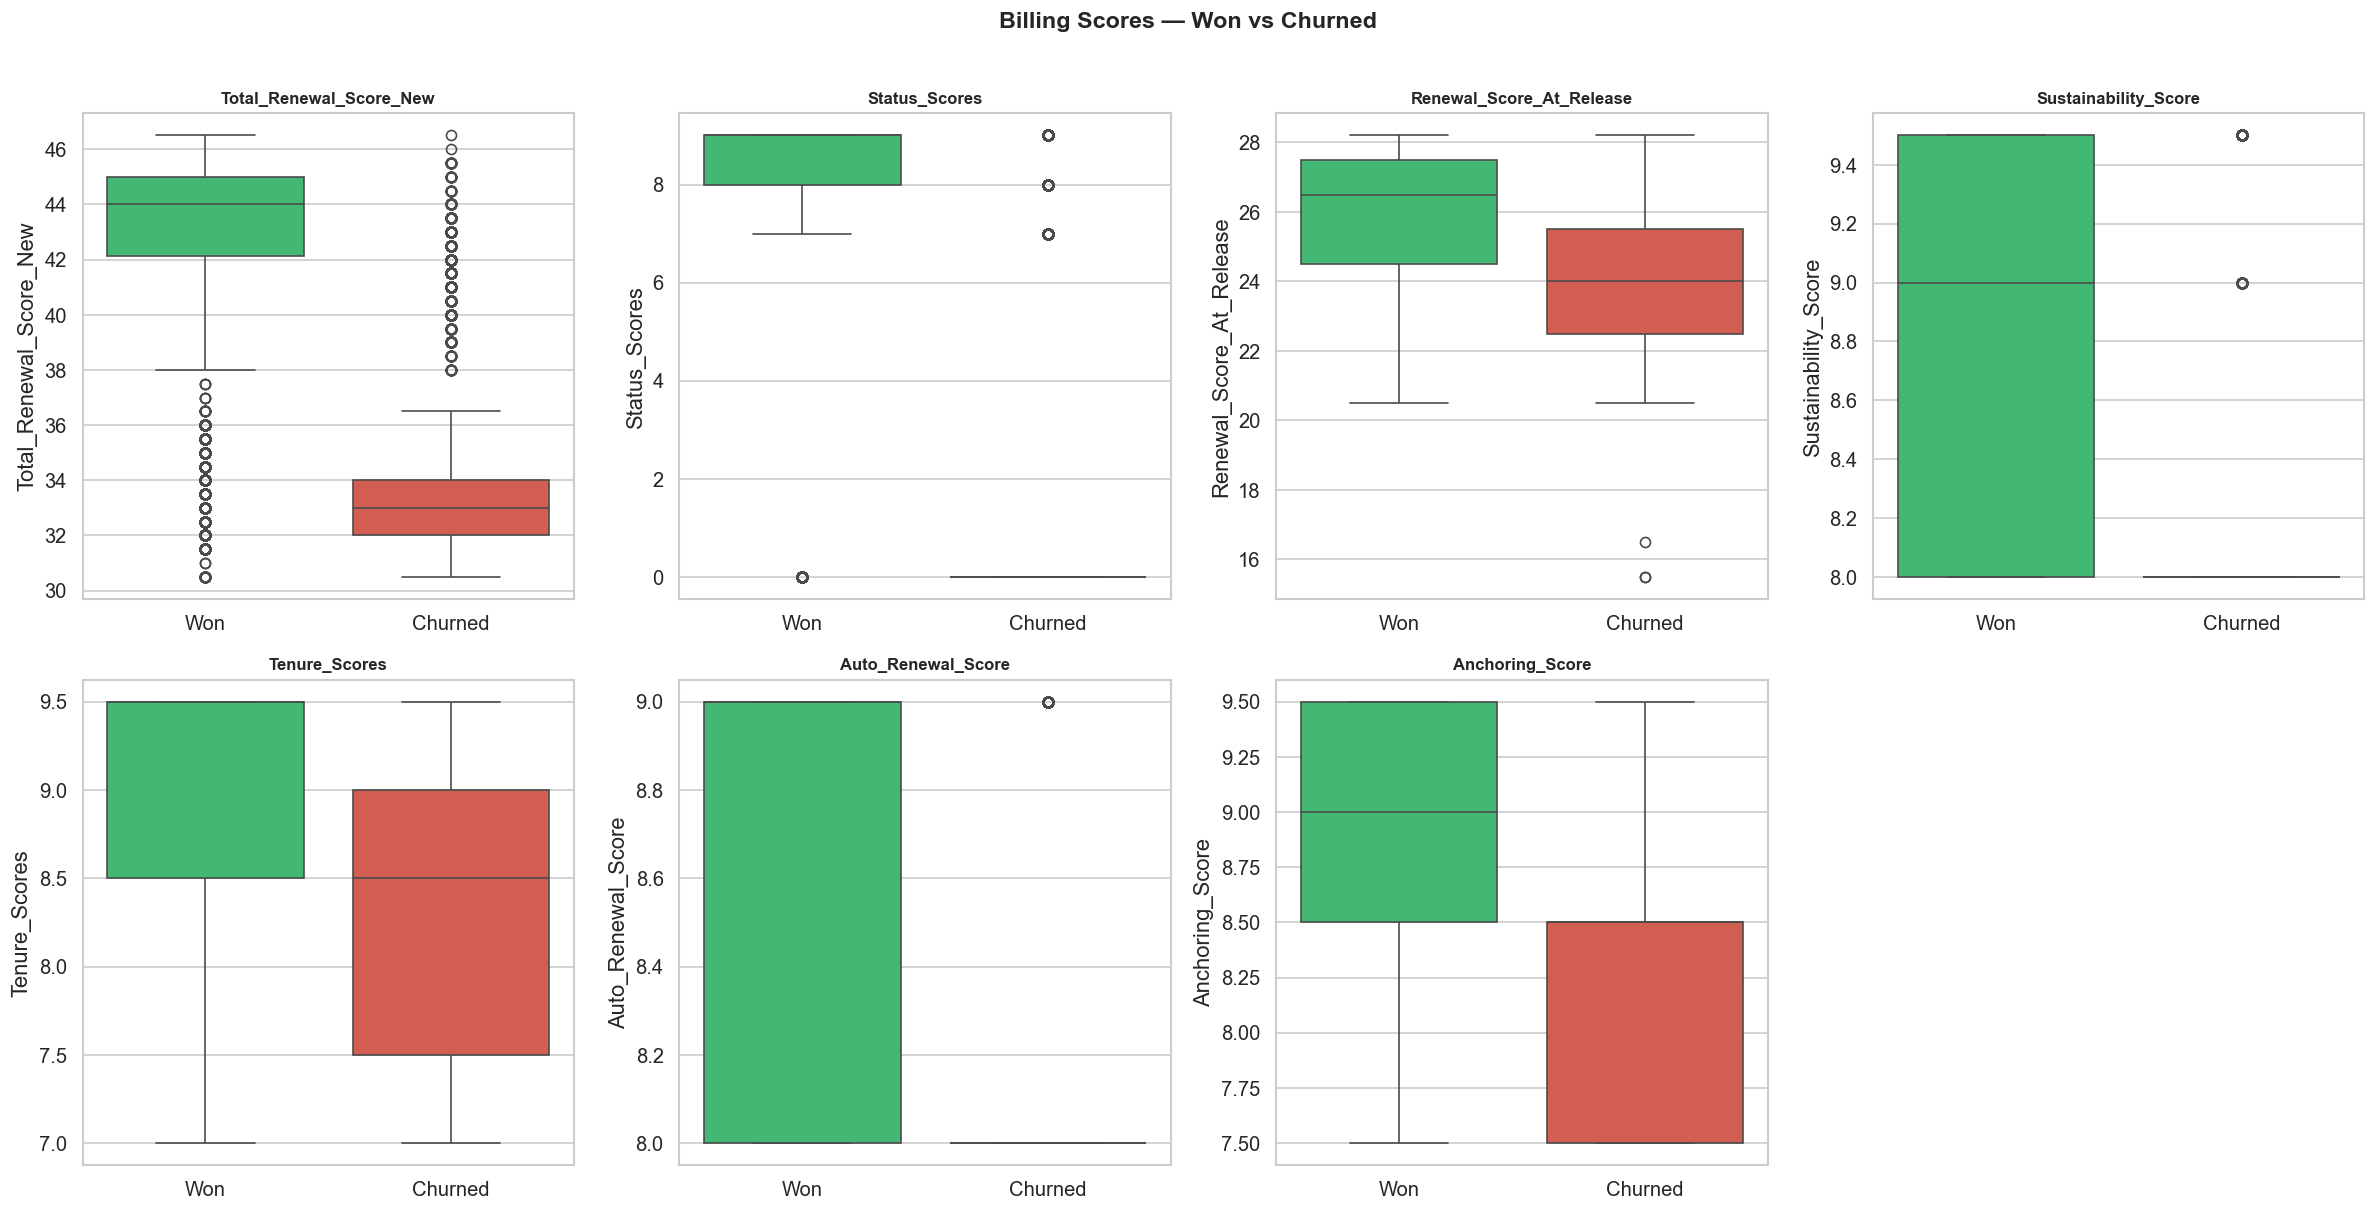

In [4]:
score_cols = [
    "Total_Renewal_Score_New", "Status_Scores", "Renewal_Score_At_Release",
    "Sustainability_Score", "Tenure_Scores", "Auto_Renewal_Score", "Anchoring_Score"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    sns.boxplot(data=df_bin, x="Prospect_Outcome", y=col, ax=axes[i],
                palette={"Won": "#2ecc71", "Churned": "#e74c3c"}, order=["Won", "Churned"])
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("")

# Hide unused subplot
axes[-1].set_visible(False)
fig.suptitle("Billing Scores — Won vs Churned", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

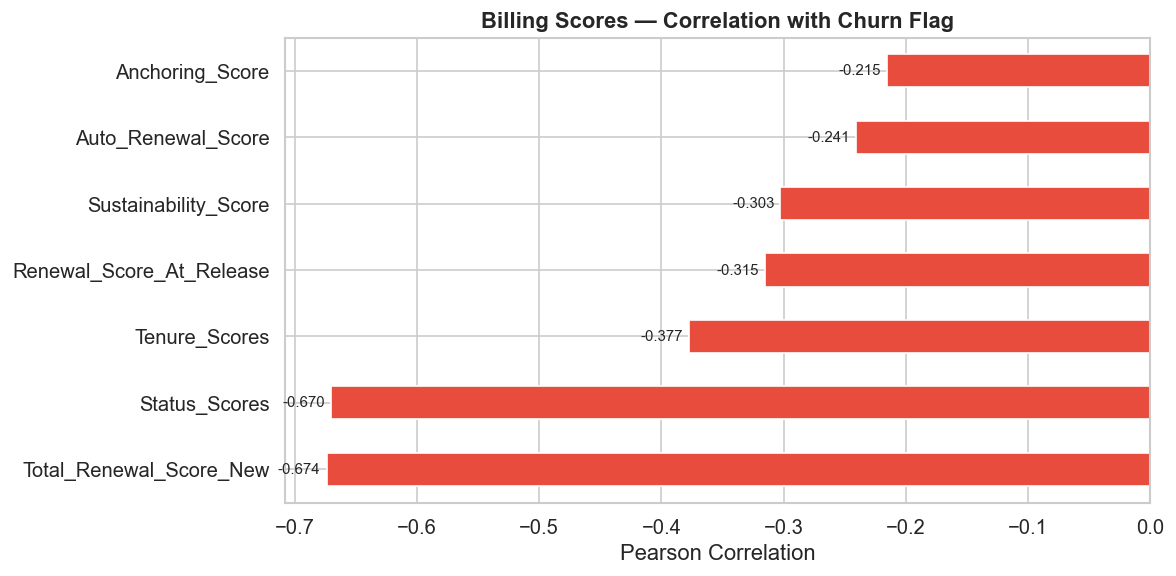

In [5]:
# Score correlations with churn
score_corrs = df_bin[score_cols].corrwith(df_bin["churn_flag"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in score_corrs.values]
score_corrs.plot.barh(ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Billing Scores — Correlation with Churn Flag", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="grey", linewidth=0.8)
for i, (val, name) in enumerate(zip(score_corrs.values, score_corrs.index)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i, f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Email / CRM Features vs Churn

These are aggregated proportions from the emails dataset — capturing pre-renewal customer engagement signals.

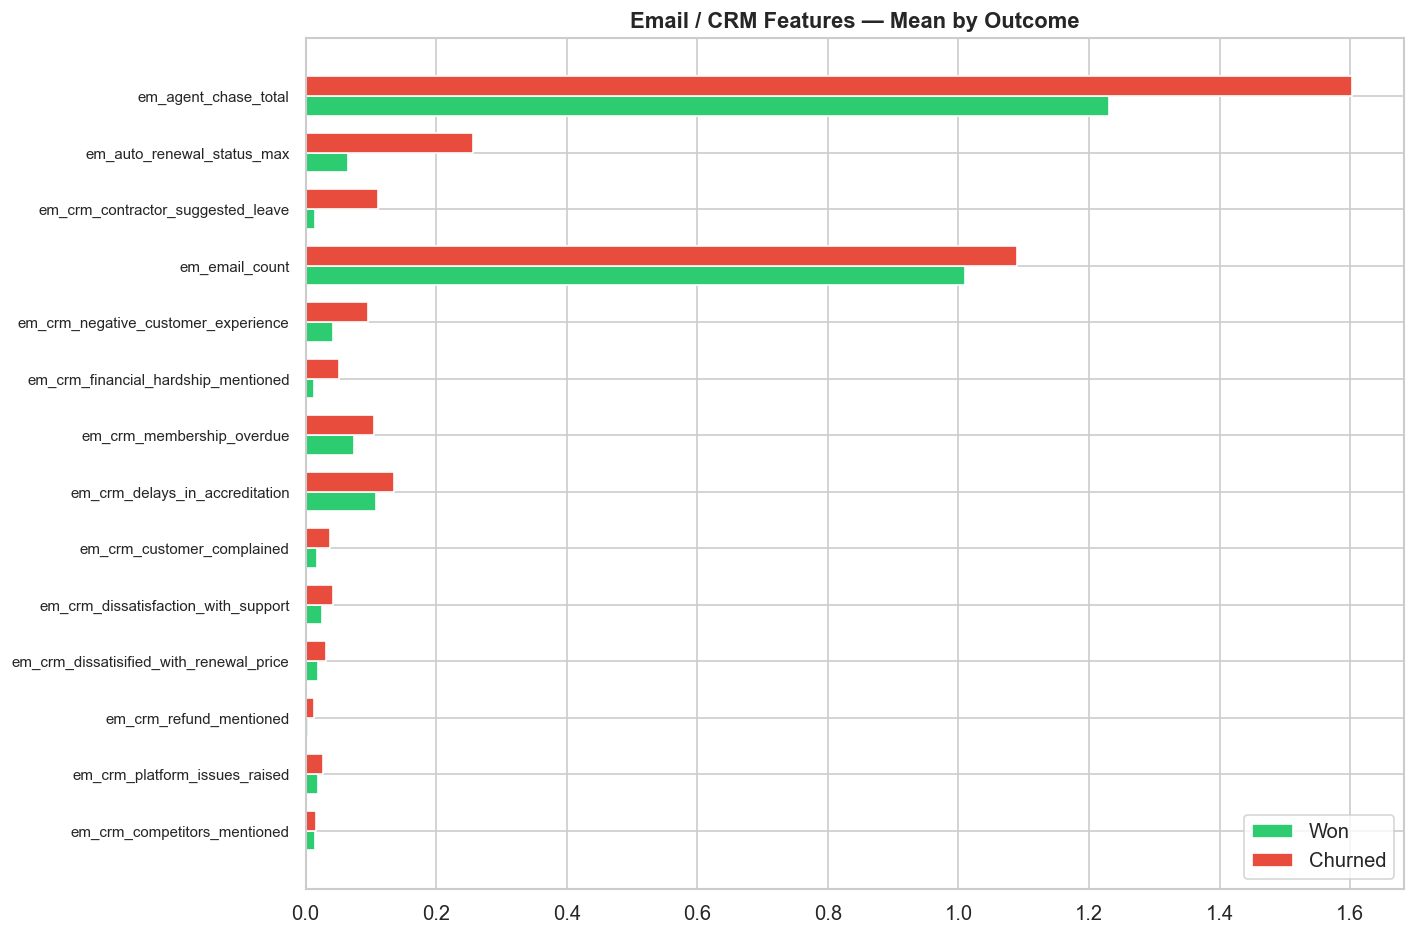

In [6]:
em_num_cols = [
    "em_crm_contractor_suggested_leave", "em_auto_renewal_status_max",
    "em_crm_financial_hardship_mentioned", "em_crm_negative_customer_experience",
    "em_crm_customer_complained", "em_crm_refund_mentioned",
    "em_crm_dissatisified_with_renewal_price", "em_crm_dissatisfaction_with_support",
    "em_crm_membership_overdue", "em_crm_delays_in_accreditation",
    "em_crm_competitors_mentioned", "em_crm_platform_issues_raised",
    "em_agent_chase_total", "em_email_count"
]

means = df_bin.groupby("Prospect_Outcome")[em_num_cols].mean().T
means["diff"] = means["Churned"] - means["Won"]
means = means.sort_values("diff", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(means))
width = 0.35
ax.barh(x - width/2, means["Won"], width, label="Won", color="#2ecc71", edgecolor="white")
ax.barh(x + width/2, means["Churned"], width, label="Churned", color="#e74c3c", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(means.index, fontsize=9)
ax.set_title("Email / CRM Features — Mean by Outcome", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

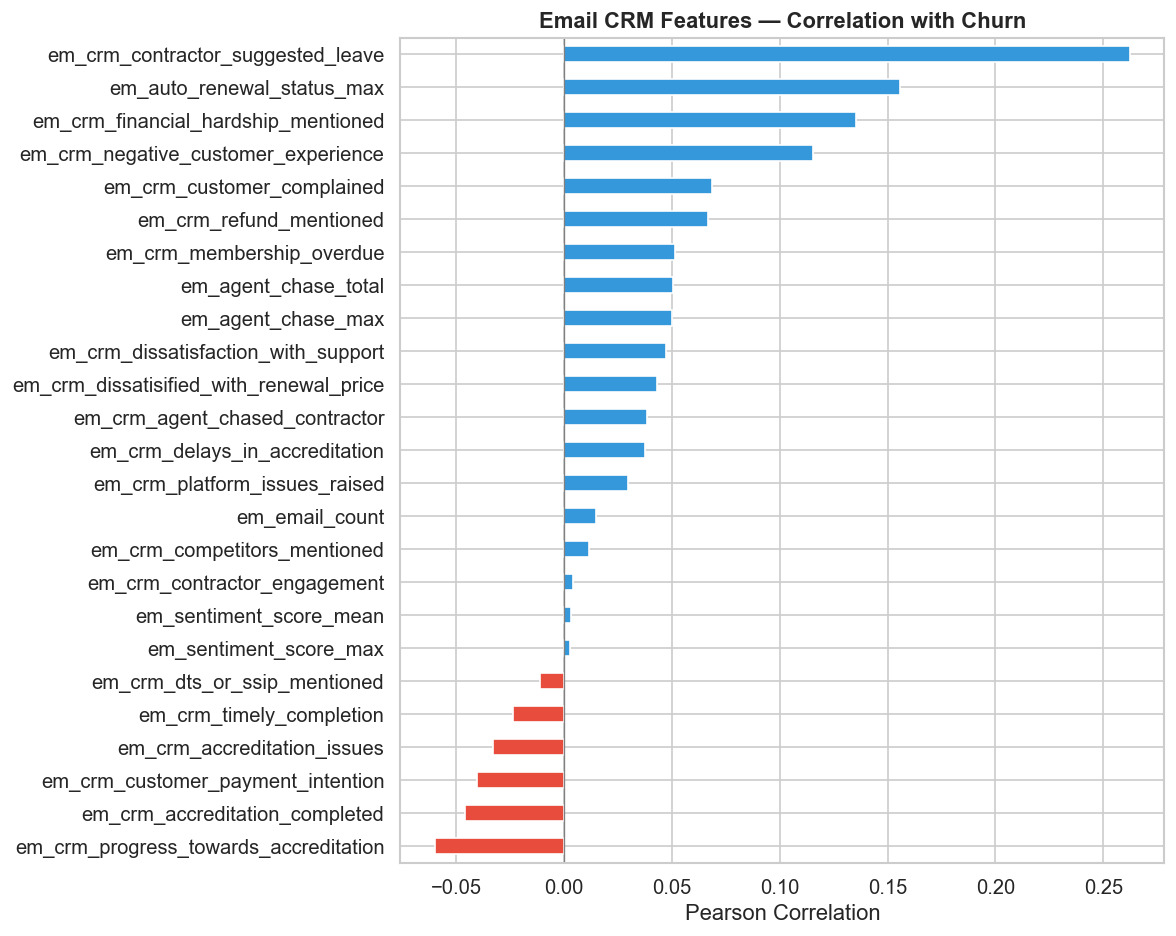

In [7]:
# Email feature correlations with churn
em_all = [c for c in df_bin.columns if c.startswith("em_") and df_bin[c].dtype in ["float64", "int64"]]
em_corrs = df_bin[em_all].corrwith(df_bin["churn_flag"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v < 0 else "#3498db" for v in em_corrs.values]
em_corrs.plot.barh(ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Email CRM Features — Correlation with Churn", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

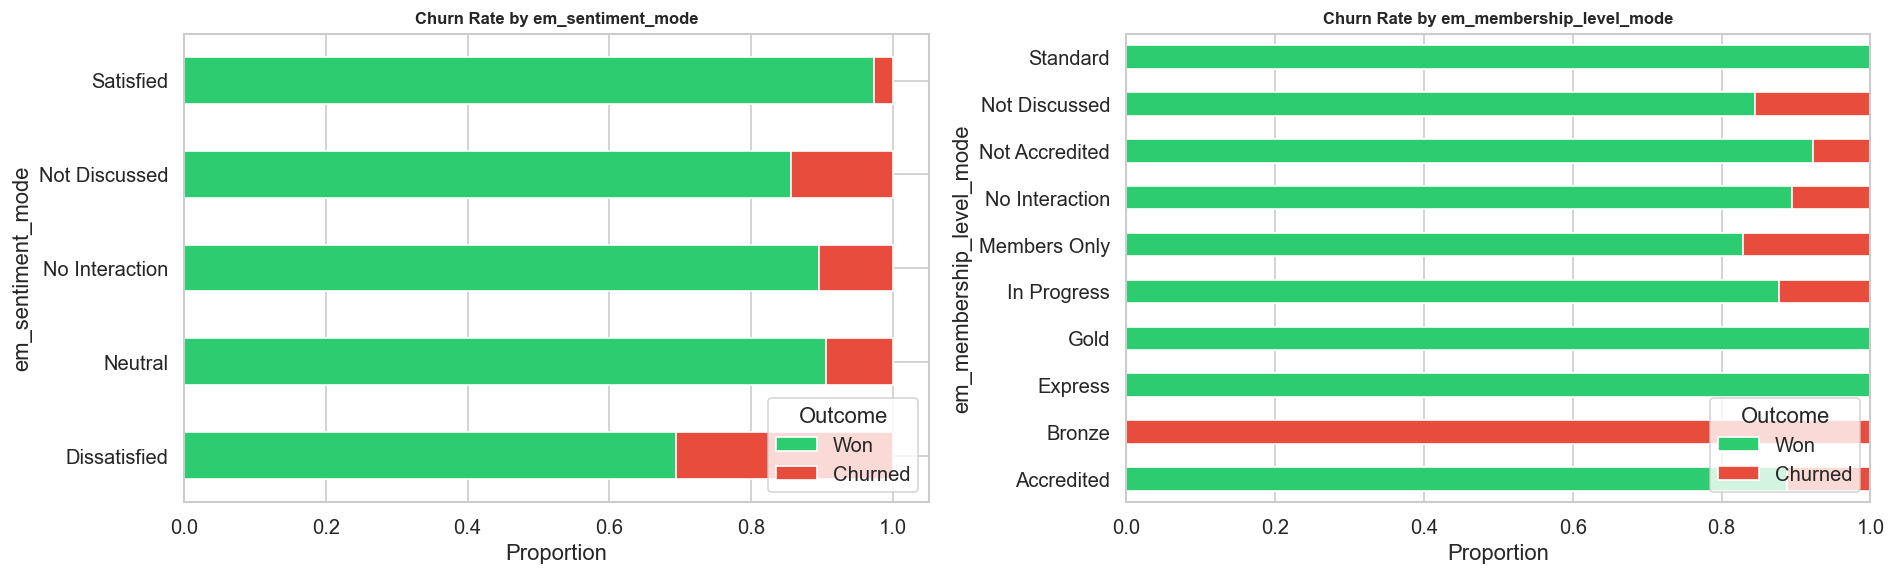

In [8]:
# Email sentiment mode vs churn
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(["em_sentiment_mode", "em_membership_level_mode"]):
    ct = pd.crosstab(df_bin[col], df_bin["Prospect_Outcome"], normalize="index")
    ct = ct.reindex(columns=["Won", "Churned"])
    ct.plot.barh(stacked=True, ax=axes[i], color=["#2ecc71", "#e74c3c"], edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Proportion")
    axes[i].legend(title="Outcome", loc="lower right")

plt.tight_layout()
plt.show()

## 4. Customer Care Call Features vs Churn

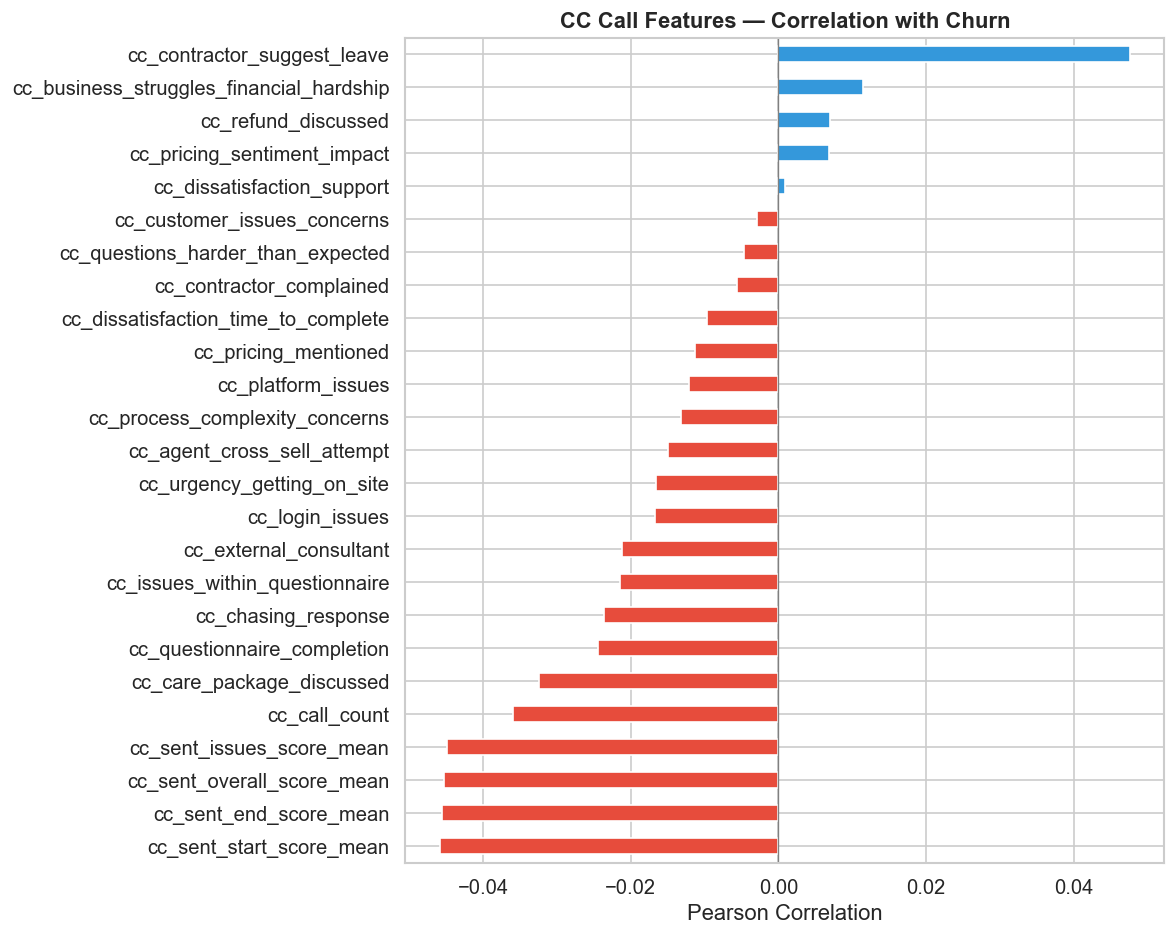

In [9]:
cc_num = [c for c in df_bin.columns if c.startswith("cc_") and df_bin[c].dtype in ["float64", "int64"]]
cc_corrs = df_bin[cc_num].corrwith(df_bin["churn_flag"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v < 0 else "#3498db" for v in cc_corrs.values]
cc_corrs.plot.barh(ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("CC Call Features — Correlation with Churn", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Renewal Call Features vs Churn

Post-renewal call signals — these are extracted from calls **after** the `Prospect_Renewal_Date`.

c:\Users\ShefaliChopra\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ShefaliChopra\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


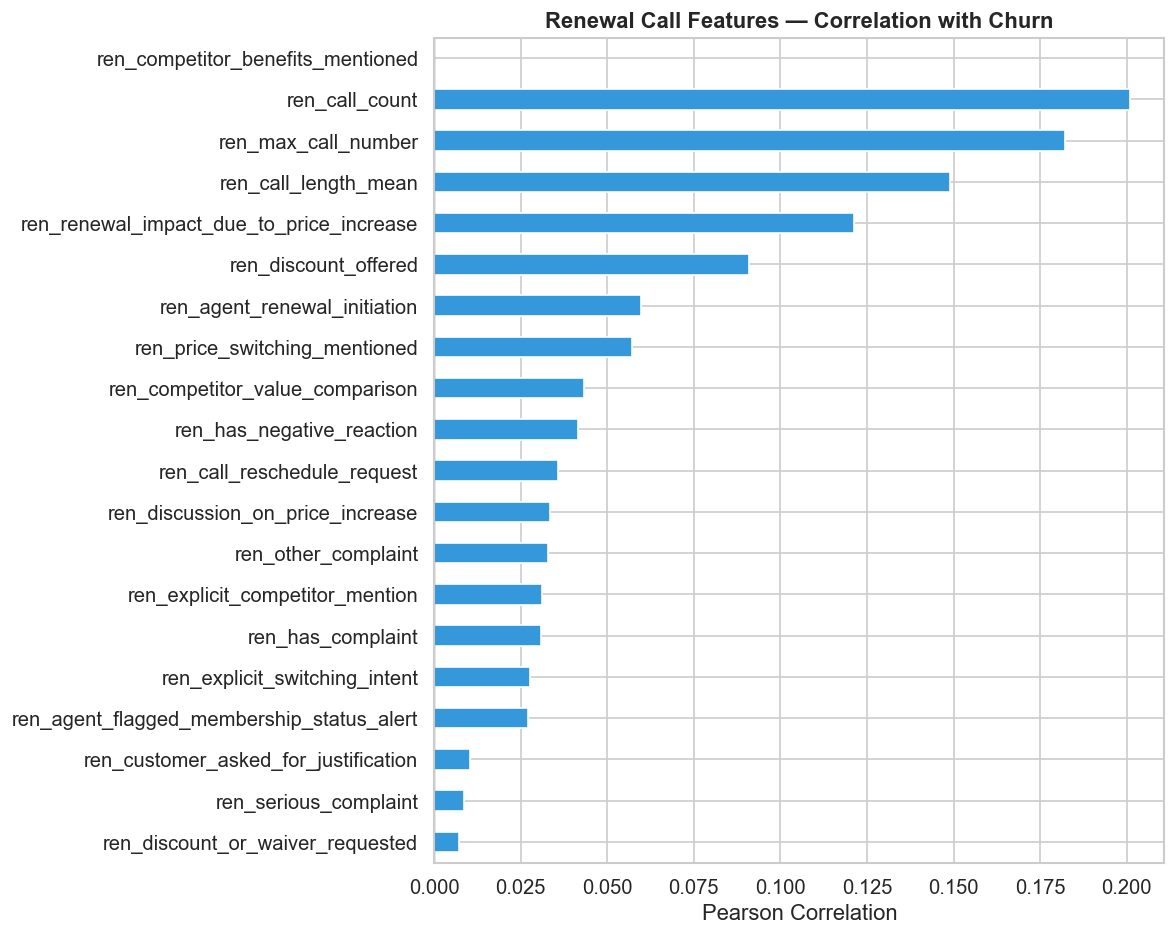

In [10]:
ren_num = [c for c in df_bin.columns if c.startswith("ren_") and df_bin[c].dtype in ["float64", "int64"]]
ren_corrs = df_bin[ren_num].corrwith(df_bin["churn_flag"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v < 0 else "#3498db" for v in ren_corrs.values]
ren_corrs.plot.barh(ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Renewal Call Features — Correlation with Churn", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

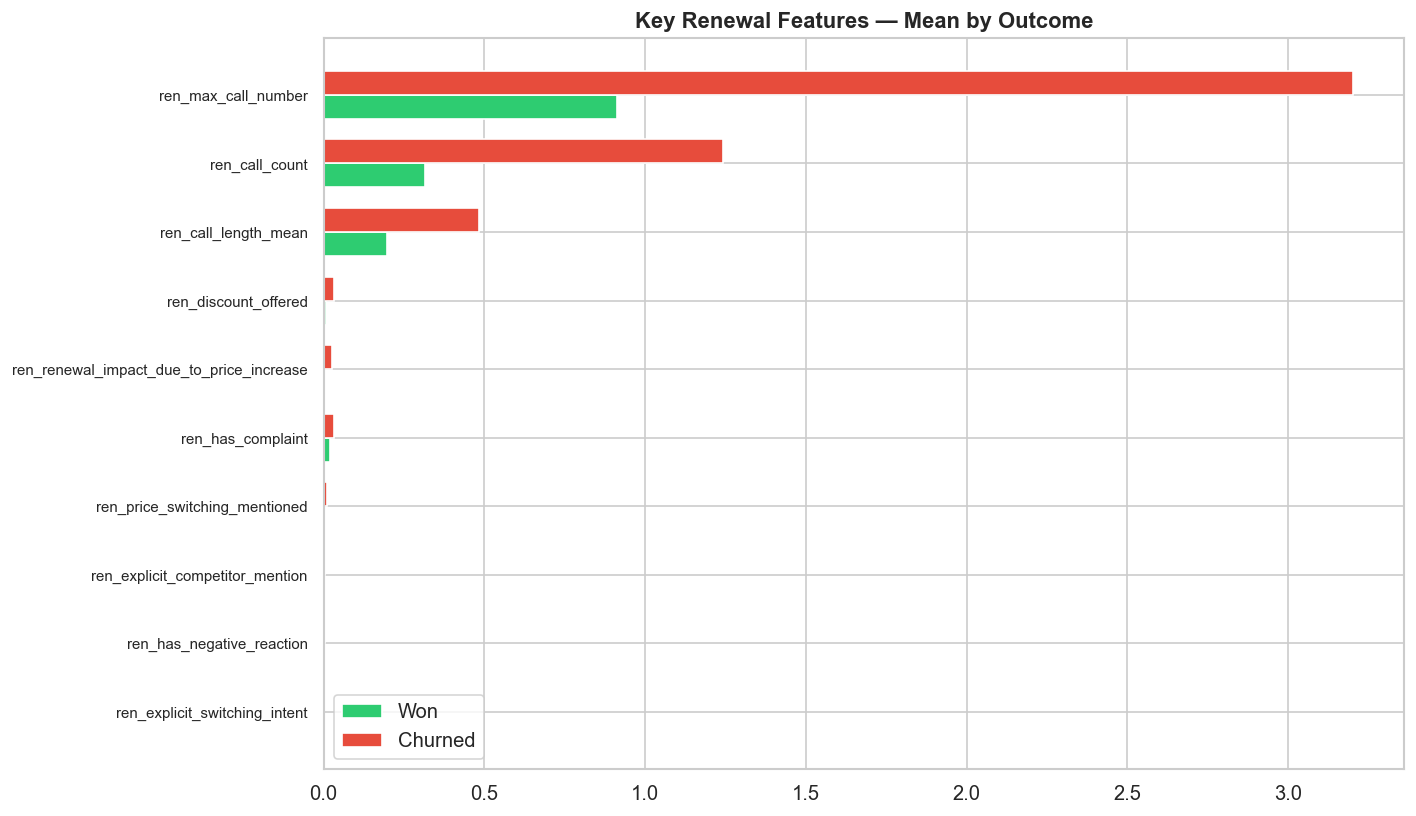

In [11]:
# Key renewal features comparison
ren_key = [
    "ren_call_count", "ren_max_call_number",
     "ren_call_length_mean",
    "ren_renewal_impact_due_to_price_increase", "ren_discount_offered",
    "ren_has_complaint", "ren_has_negative_reaction",
    "ren_explicit_switching_intent", "ren_explicit_competitor_mention",
    "ren_price_switching_mentioned"
]

means_ren = df_bin.groupby("Prospect_Outcome")[ren_key].mean().T
means_ren["diff"] = means_ren["Churned"] - means_ren["Won"]
means_ren = means_ren.sort_values("diff", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(means_ren))
width = 0.35
ax.barh(x - width/2, means_ren["Won"], width, label="Won", color="#2ecc71", edgecolor="white")
ax.barh(x + width/2, means_ren["Churned"], width, label="Churned", color="#e74c3c", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(means_ren.index, fontsize=9)
ax.set_title("Key Renewal Features — Mean by Outcome", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

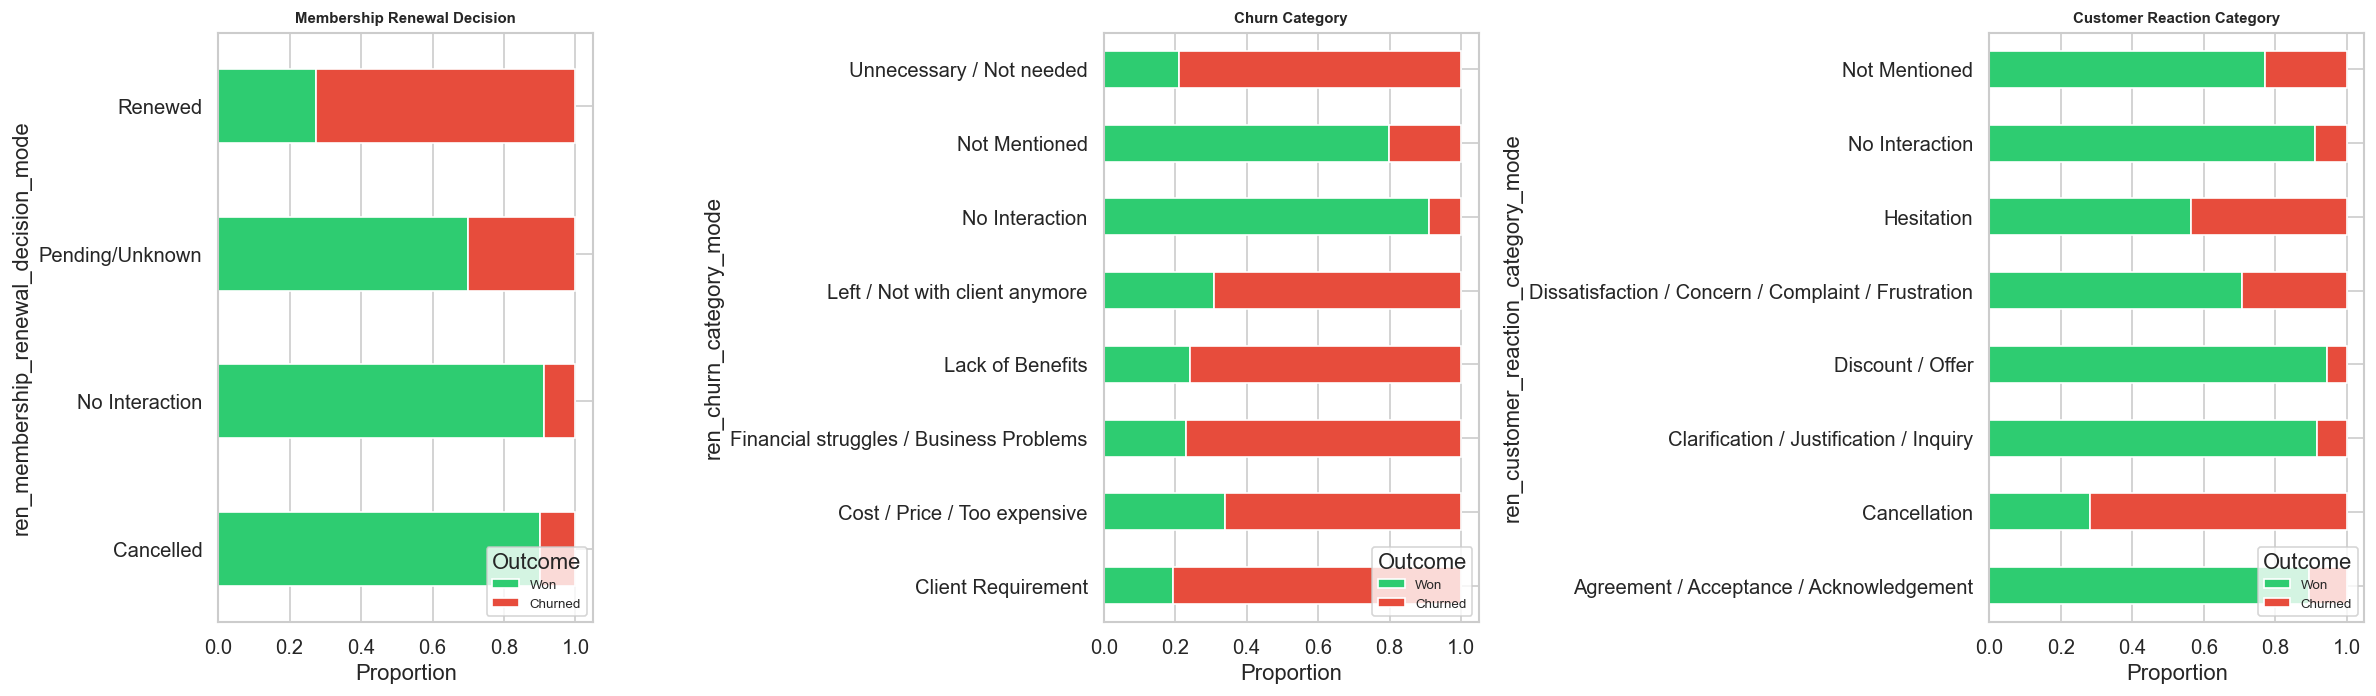

In [12]:
# Key categorical renewal features
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cat_ren_cols = [
    "ren_membership_renewal_decision_mode",
    "ren_churn_category_mode",
    "ren_customer_reaction_category_mode"
]

for i, col in enumerate(cat_ren_cols):
    ct = pd.crosstab(df_bin[col], df_bin["Prospect_Outcome"], normalize="index")
    ct = ct.reindex(columns=["Won", "Churned"])
    # Only show top categories by count (exclude No Interaction)
    top_cats = df_bin[col].value_counts().head(8).index
    ct_top = ct.loc[ct.index.isin(top_cats)]
    ct_top.plot.barh(stacked=True, ax=axes[i], color=["#2ecc71", "#e74c3c"], edgecolor="white")
    axes[i].set_title(col.replace("ren_", "").replace("_mode", "").replace("_", " ").title(),
                      fontweight="bold", fontsize=9)
    axes[i].set_xlabel("Proportion")
    axes[i].legend(title="Outcome", loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Top Feature Correlations with Churn

Overall ranking of all numeric features by absolute correlation with the churn flag.

c:\Users\ShefaliChopra\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ShefaliChopra\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


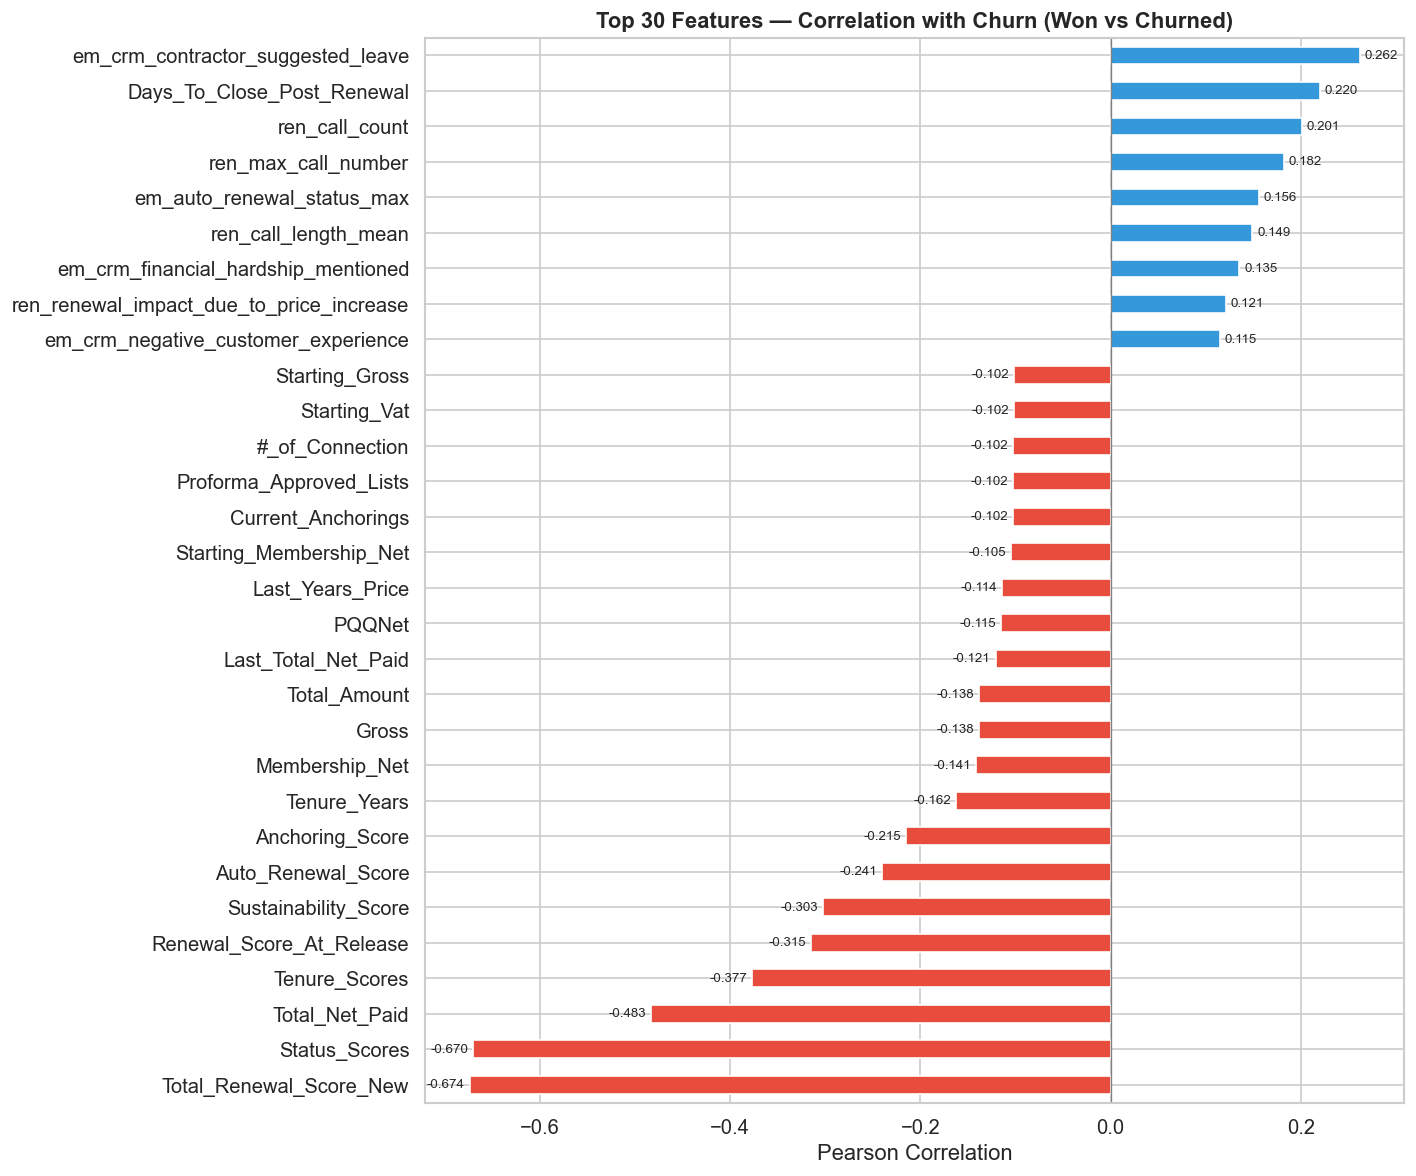

In [13]:
# Compute correlations for ALL numeric columns with churn
num_cols = df_bin.select_dtypes(include=[np.number]).columns.drop("churn_flag", errors="ignore")
all_corrs = df_bin[num_cols].corrwith(df_bin["churn_flag"])
top30 = all_corrs.abs().sort_values(ascending=False).head(30)
top30_signed = all_corrs.loc[top30.index].sort_values()

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ["#e74c3c" if v < 0 else "#3498db" for v in top30_signed.values]
top30_signed.plot.barh(ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Top 30 Features — Correlation with Churn (Won vs Churned)", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="grey", linewidth=0.8)
for i, (val, name) in enumerate(zip(top30_signed.values, top30_signed.index)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i, f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

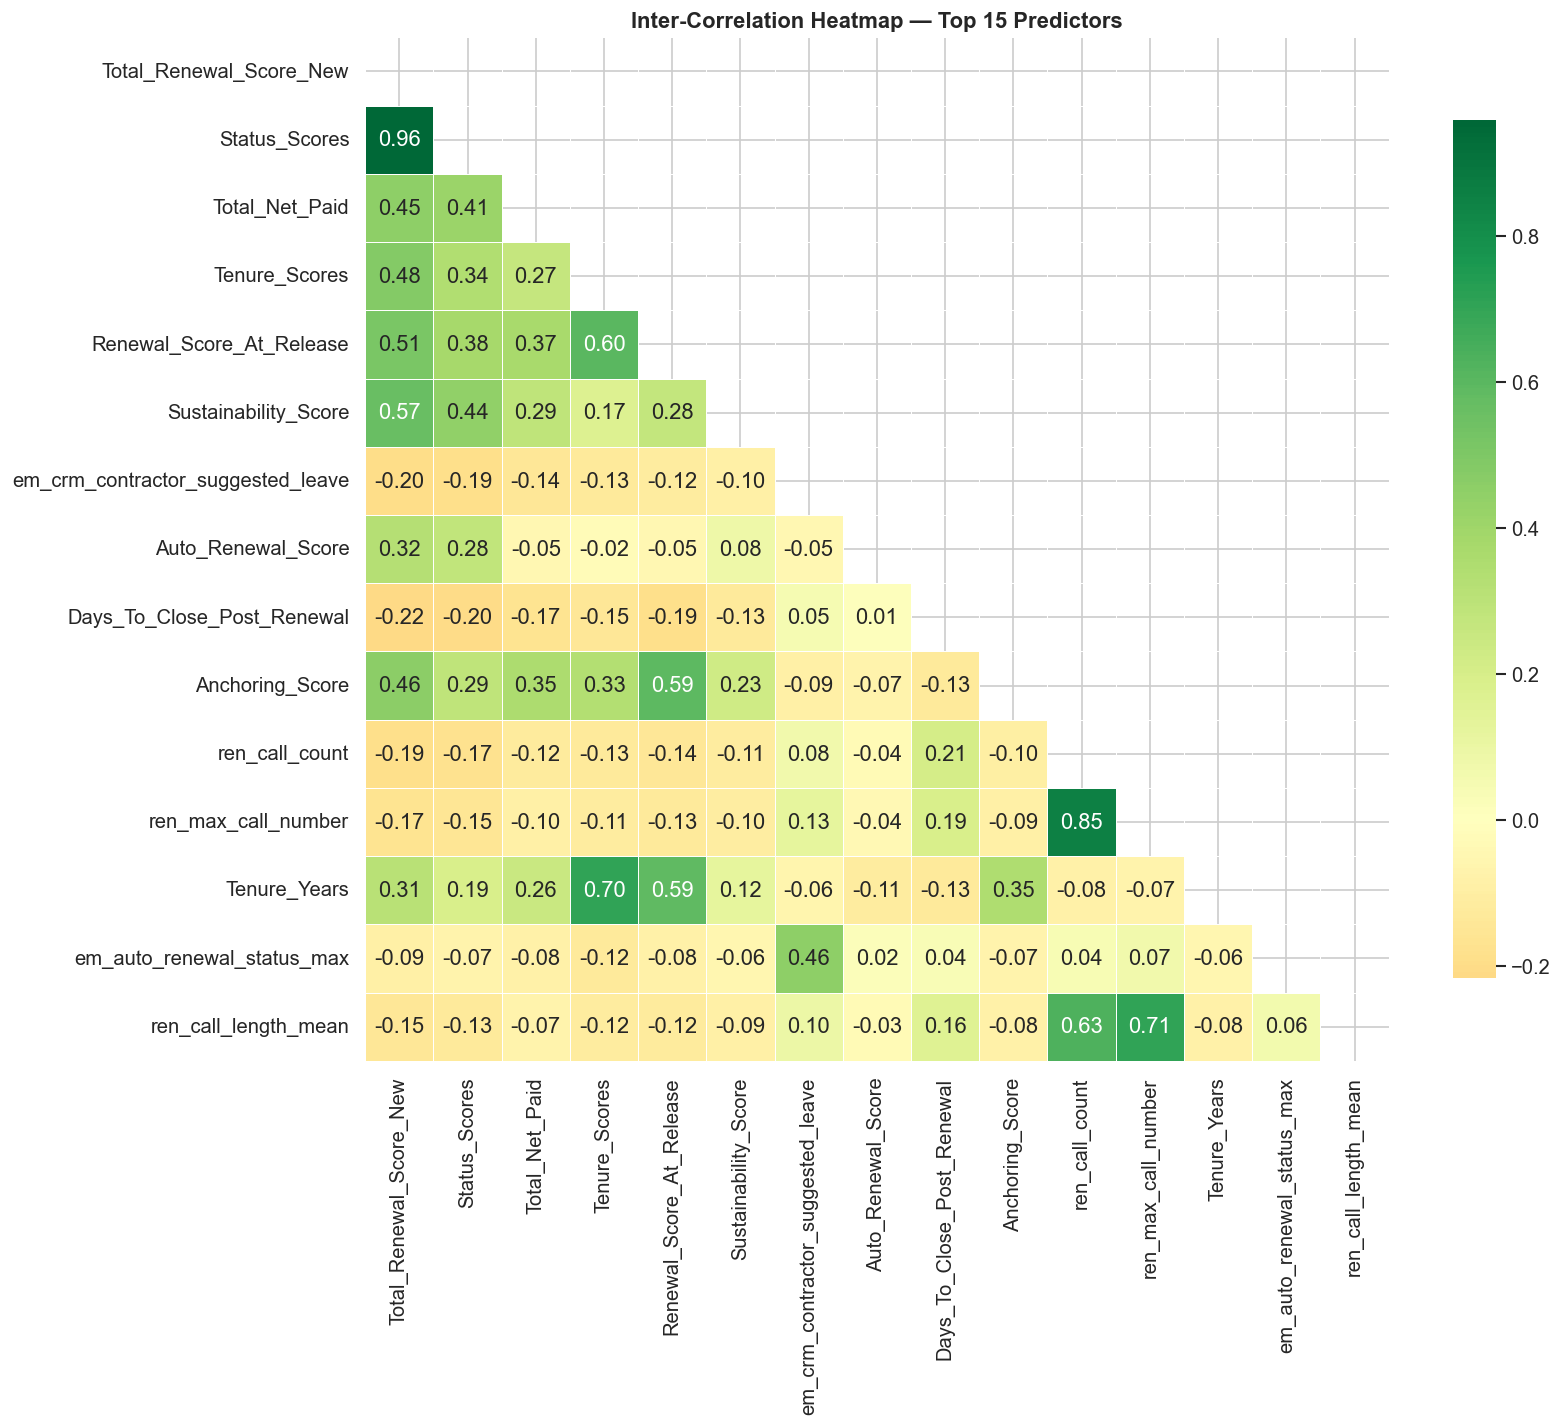

In [14]:
# Heatmap of inter-correlations among top features
top_features = top30.index[:15].tolist()
corr_matrix = df_bin[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Inter-Correlation Heatmap — Top 15 Predictors", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Key Categorical Features & Churn Rates

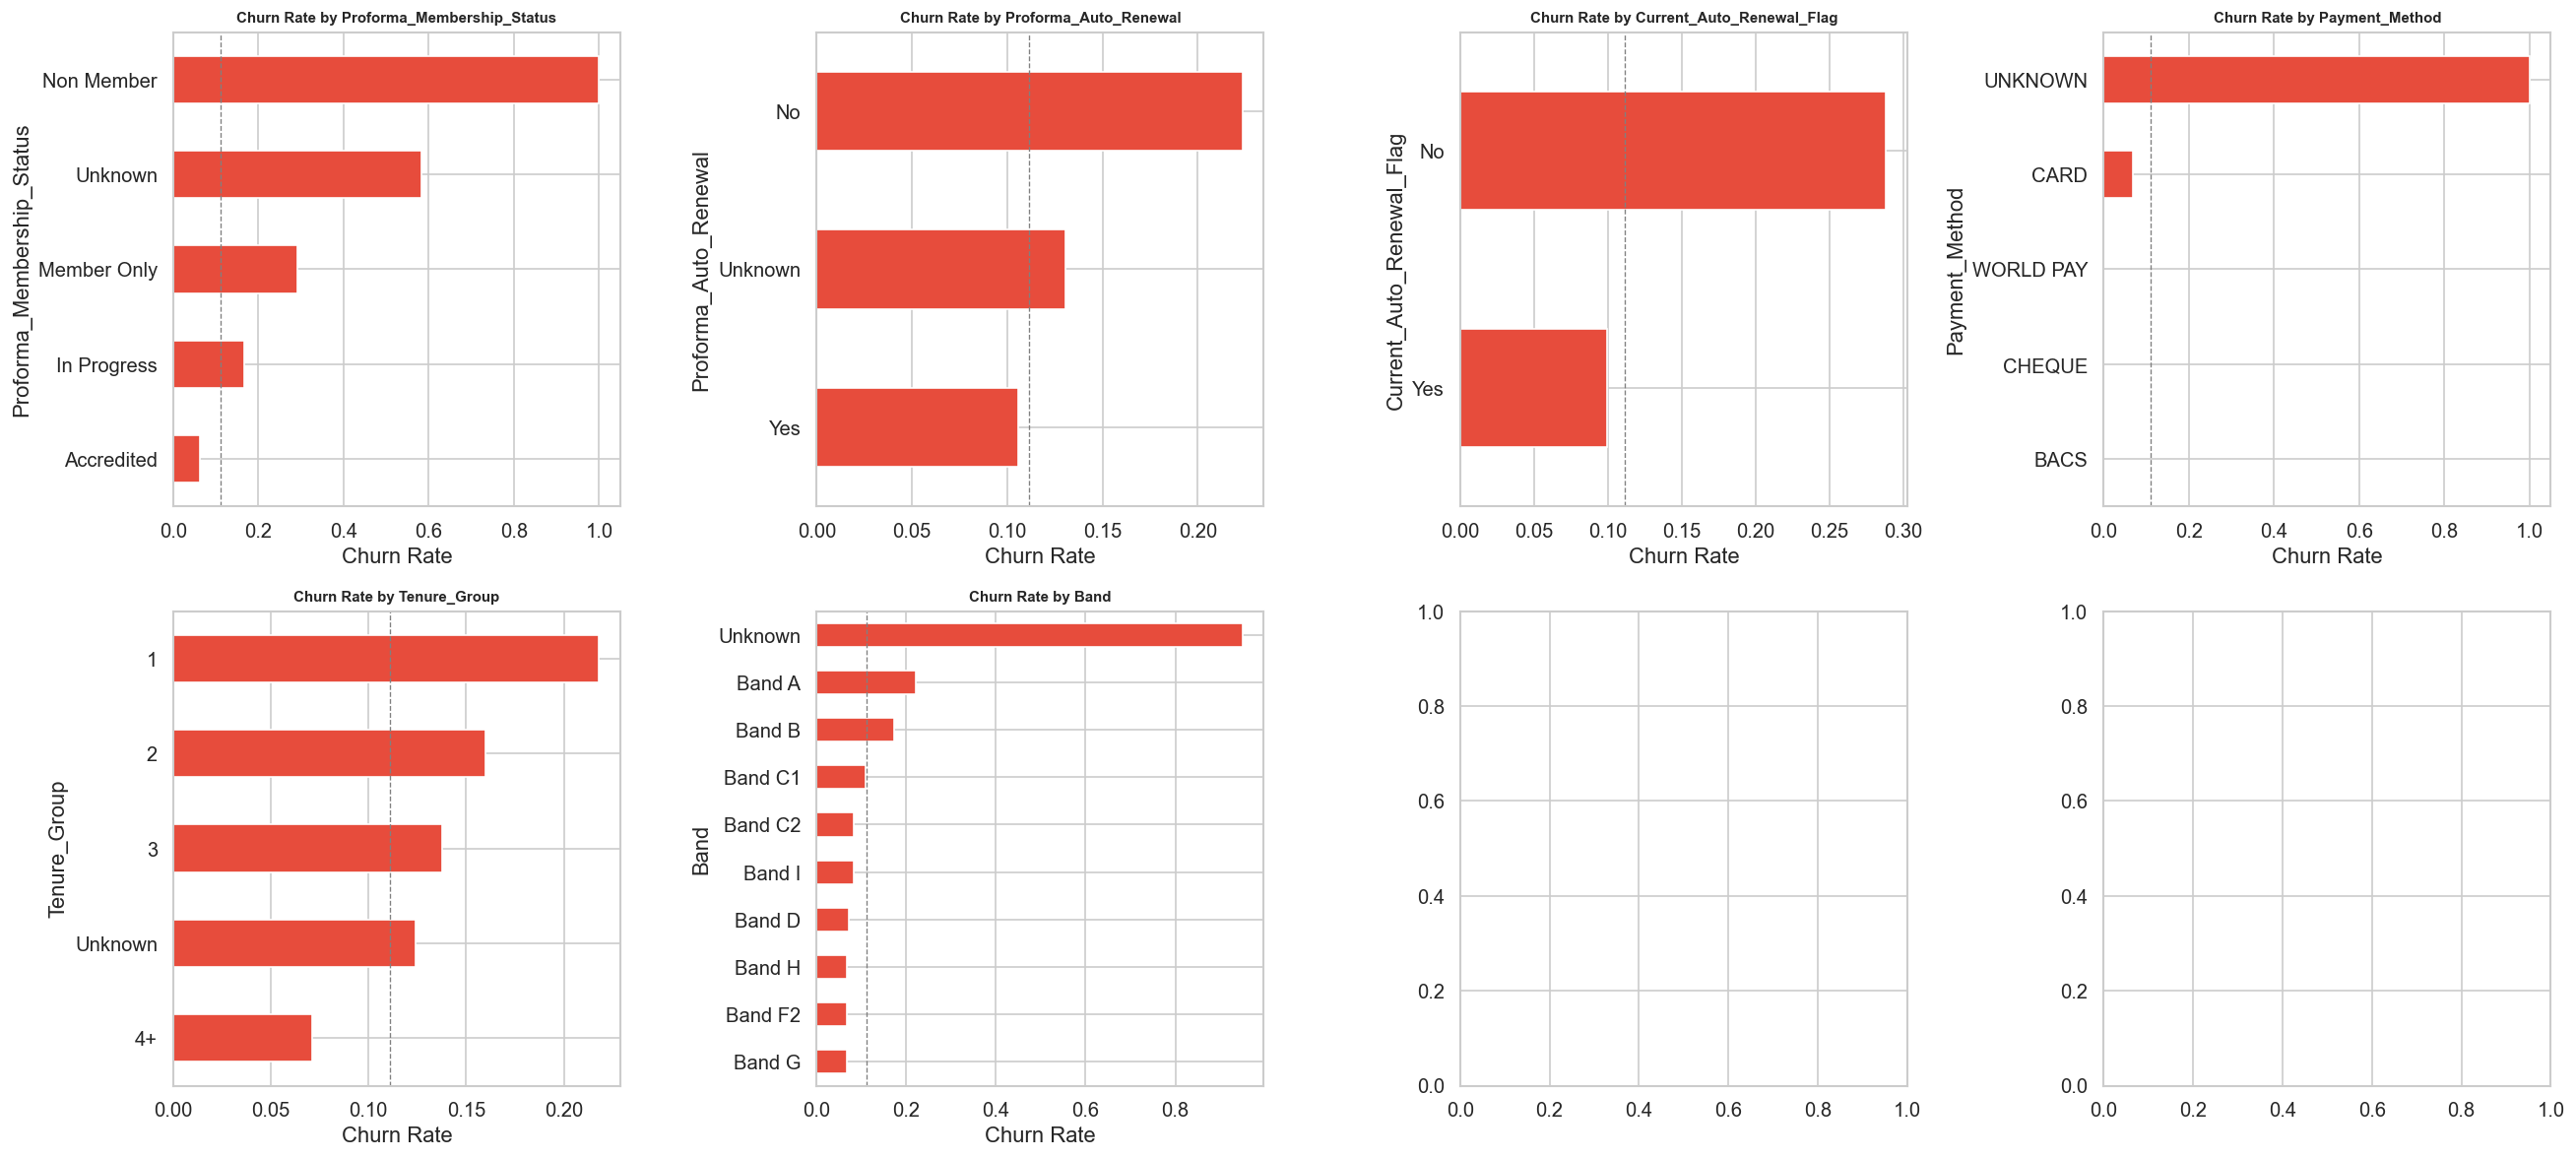

In [15]:
cat_features = [
    "Proforma_Membership_Status",
    "Proforma_Auto_Renewal", "Current_Auto_Renewal_Flag",
    "Payment_Method",
    "Tenure_Group", "Band"
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df_bin.groupby(col)["churn_flag"].mean().sort_values(ascending=True)
    # Only top 10 categories
    if len(churn_rate) > 10:
        churn_rate = churn_rate.tail(10)
    churn_rate.plot.barh(ax=axes[i], color="#e74c3c", edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold", fontsize=9)
    axes[i].set_xlabel("Churn Rate")
    axes[i].axvline(df_bin["churn_flag"].mean(), color="grey", linestyle="--", linewidth=0.8, label="Overall")

plt.tight_layout()
plt.show()

## 8. Summary — Feature Importance Table

Consolidated view of the top features ranked by absolute correlation with churn.

In [16]:
# Build summary table
summary = pd.DataFrame({
    "Feature": all_corrs.index,
    "Corr_with_Churn": all_corrs.values
})
summary["Abs_Corr"] = summary["Corr_with_Churn"].abs()
summary["Source"] = summary["Feature"].apply(
    lambda x: "Email/CRM" if x.startswith("em_") else
              "CC Calls" if x.startswith("cc_") else
              "Renewal Calls" if x.startswith("ren_") else "Billing"
)
summary["Direction"] = summary["Corr_with_Churn"].apply(
    lambda x: "Higher → More Churn" if x > 0 else "Higher → Less Churn"
)
summary = summary.sort_values("Abs_Corr", ascending=False).head(40).reset_index(drop=True)
summary.index += 1
summary[["Feature", "Source", "Corr_with_Churn", "Direction"]]

,Feature,Source,Corr_with_Churn,Direction
1,Total_Renewal_Score_New,Billing,-0.673765,Higher → Less Churn
2,Status_Scores,Billing,-0.670269,Higher → Less Churn
3,Total_Net_Paid,Billing,-0.483233,Higher → Less Churn
4,Tenure_Scores,Billing,-0.377107,Higher → Less Churn
5,Renewal_Score_At_Release,Billing,-0.315323,Higher → Less Churn
6,Sustainability_Score,Billing,-0.302563,Higher → Less Churn
7,em_crm_contractor_suggested_leave,Email/CRM,0.262268,Higher → More Churn
8,Auto_Renewal_Score,Billing,-0.240549,Higher → Less Churn
9,Days_To_Close_Post_Renewal,Billing,0.220009,Higher → More Churn
10,Anchoring_Score,Billing,-0.215078,Higher → Less Churn


Top 40 features by data source:
Source
Billing          26
Email/CRM         7
Renewal Calls     7
Name: count, dtype: int64


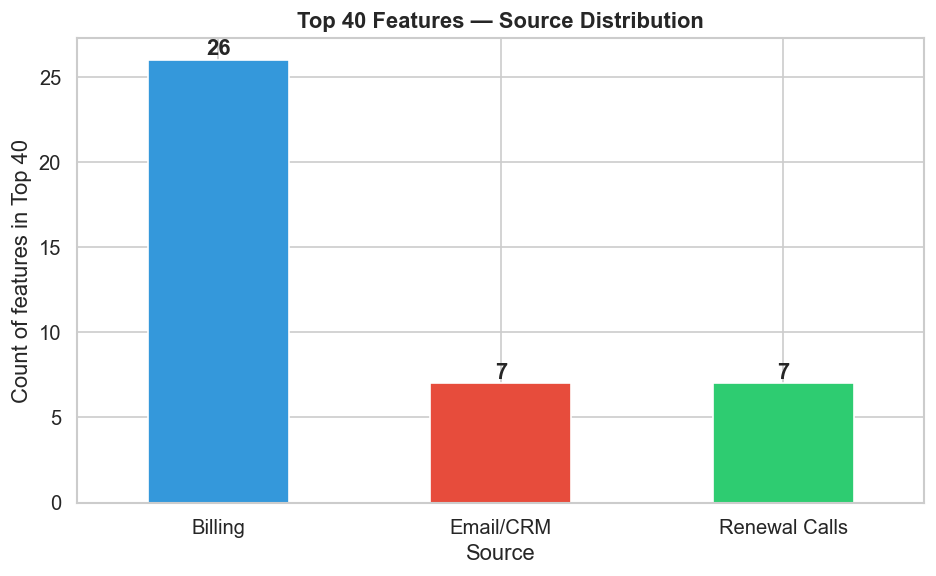

In [17]:
# Breakdown: how many top features come from each source?
print("Top 40 features by data source:")
print(summary["Source"].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
source_counts = summary["Source"].value_counts()
source_counts.plot.bar(ax=ax, color=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"], edgecolor="white")
ax.set_title("Top 40 Features — Source Distribution", fontweight="bold")
ax.set_ylabel("Count of features in Top 40")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(source_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusion & Key Findings

### Most Critical Features for Model Training

**Tier 1 — Strongest Predictors (|corr| > 0.2):**
1. Total_Renewal_Score_New (−0.67) — The single strongest predictor. Lower scores = much higher churn.
2. Status_Scores (−0.67) — Nearly tied. Churned customers have near-zero status scores.
3. Total_Net_Paid (−0.48) — Higher-paying customers churn much less.
4. Tenure_Scores (−0.38) — Longer tenure = lower churn.
5. Renewal_Score_At_Release (−0.32) — Lower initial renewal scores → more churn.
6. Sustainability_Score (−0.30) — Lower sustainability → churn.
7. em_crm_contractor_suggested_leave (+0.26) — **Top CRM signal:** contractors actively suggesting they want to leave.
8. Auto_Renewal_Score (−0.24) — Not having auto renewal → churn.
9. Days_To_Close_Post_Renewal (+0.22) — Delayed closure strongly indicates churn.
10. Anchoring_Score (−0.22) — Fewer anchored connections → churn.

**Tier 2 — Important (|corr| 0.1–0.2):**
- ren_call_count (+0.20), ren_max_call_number (+0.18) — More renewal calls = more churn attempts.
- ren_friction_score_mean/max (+0.16) — Higher call friction = churn.
- em_auto_renewal_status_max (+0.16) — Auto-renewal status flagged in emails.
- em_crm_financial_hardship_mentioned (+0.14) — Financial struggles mentioned.
- ren_renewal_impact_due_to_price_increase (+0.12) — Price impact concerns.
- em_crm_negative_customer_experience (+0.12) — Negative experiences flagged.

